# Credit Risk EDA — Xente eCommerce Transaction Data
## Exploratory Data Analysis for Bati Bank Credit Scoring Model

**Goal:** Understand the structure, distributions, and patterns in the Xente transaction data
to guide feature engineering and proxy target variable construction.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8')

print("All libraries loaded successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All libraries loaded successfully!
Pandas version: 2.3.3
NumPy version: 2.4.6


In [2]:
# Load the dataset
df = pd.read_csv('../data/raw/data.csv')

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn names:\n{list(df.columns)}")

Dataset shape: (95662, 16)
Rows: 95,662
Columns: 16

Column names:
['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'Amount', 'Value', 'TransactionStartTime', 'PricingStrategy', 'FraudResult']


In [3]:
# First 5 rows
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.00,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.00,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.00,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.00,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.00,644,2018-11-15T03:34:21Z,2,0


In [4]:
# Data types and non-null counts
print("=== DATA TYPES & NON-NULL COUNTS ===")
print(df.info())

=== DATA TYPES & NON-NULL COUNTS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-n

In [5]:
# Missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
})
print("=== MISSING VALUES ===")
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

=== MISSING VALUES ===
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []

Total missing values: 0


In [6]:
# Summary statistics for numerical columns
print("=== NUMERICAL FEATURES SUMMARY ===")
df[['Amount', 'Value', 'PricingStrategy', 'FraudResult']].describe()

=== NUMERICAL FEATURES SUMMARY ===


,Amount,Value,PricingStrategy,FraudResult
count,95662.00,95662.00,95662.00,95662.00
mean,6717.85,9900.58,2.26,0.00
std,123306.80,123122.09,0.73,0.04
min,-1000000.00,2.00,0.00,0.00
25%,-50.00,275.00,2.00,0.00
50%,1000.00,1000.00,2.00,0.00
75%,2800.00,5000.00,2.00,0.00
max,9880000.00,9880000.00,4.00,1.00


=== FRAUD DISTRIBUTION ===
Non-fraudulent (0): 95,469 (99.80%)
Fraudulent (1):     193 (0.20%)


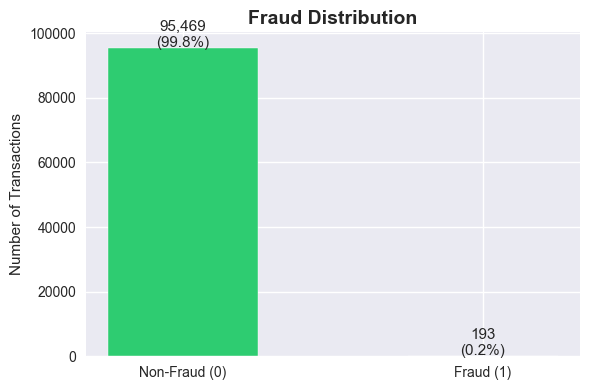

In [7]:
# Fraud distribution
fraud_counts = df['FraudResult'].value_counts()
fraud_pct = df['FraudResult'].value_counts(normalize=True) * 100

print("=== FRAUD DISTRIBUTION ===")
print(f"Non-fraudulent (0): {fraud_counts[0]:,} ({fraud_pct[0]:.2f}%)")
print(f"Fraudulent (1):     {fraud_counts[1]:,} ({fraud_pct[1]:.2f}%)")

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.bar(['Non-Fraud (0)', 'Fraud (1)'], fraud_counts.values,
       color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
ax.set_title('Fraud Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Transactions')
for i, v in enumerate(fraud_counts.values):
    ax.text(i, v + 200, f'{v:,}\n({fraud_pct.values[i]:.1f}%)',
            ha='center', fontsize=11)
plt.tight_layout()
plt.show()

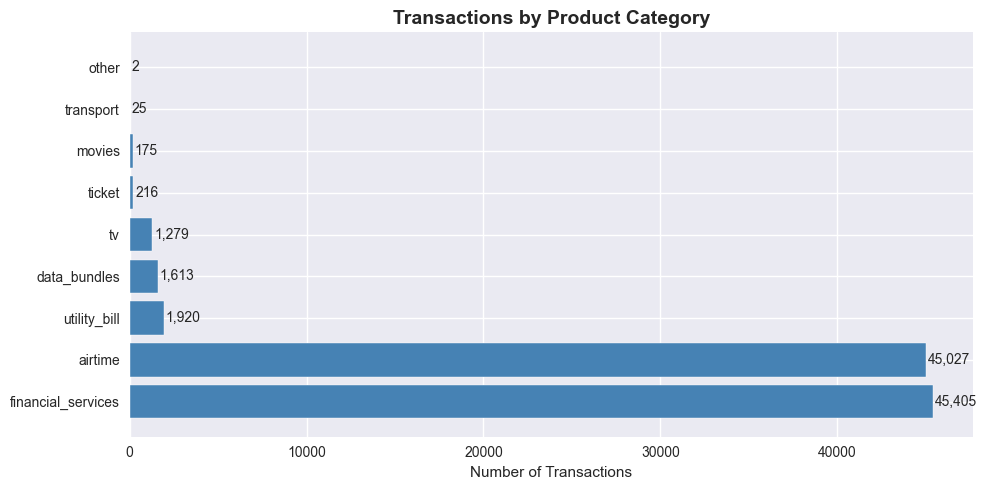

In [8]:
# Product category distribution
cat_counts = df['ProductCategory'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cat_counts.index, cat_counts.values,
               color='steelblue', edgecolor='white')
ax.set_title('Transactions by Product Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Transactions')
for bar, val in zip(bars, cat_counts.values):
    ax.text(val + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

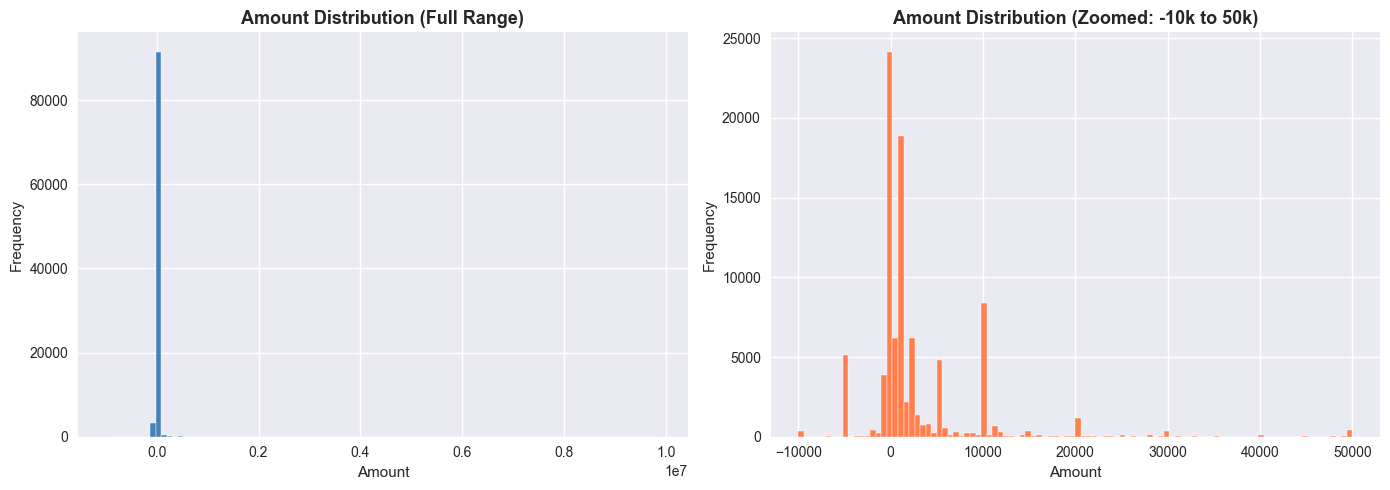

Transactions with negative Amount: 38,189 (39.9%)
Transactions with positive Amount: 57,473 (60.1%)


In [9]:
# Amount distribution - showing the spread
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full distribution
axes[0].hist(df['Amount'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Amount Distribution (Full Range)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

# Right: zoomed in (-10000 to 50000) to see most transactions
df_zoom = df[(df['Amount'] >= -10000) & (df['Amount'] <= 50000)]
axes[1].hist(df_zoom['Amount'], bins=100, color='coral', edgecolor='white')
axes[1].set_title('Amount Distribution (Zoomed: -10k to 50k)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Transactions with negative Amount: {(df['Amount'] < 0).sum():,} ({(df['Amount'] < 0).mean()*100:.1f}%)")
print(f"Transactions with positive Amount: {(df['Amount'] > 0).sum():,} ({(df['Amount'] > 0).mean()*100:.1f}%)")

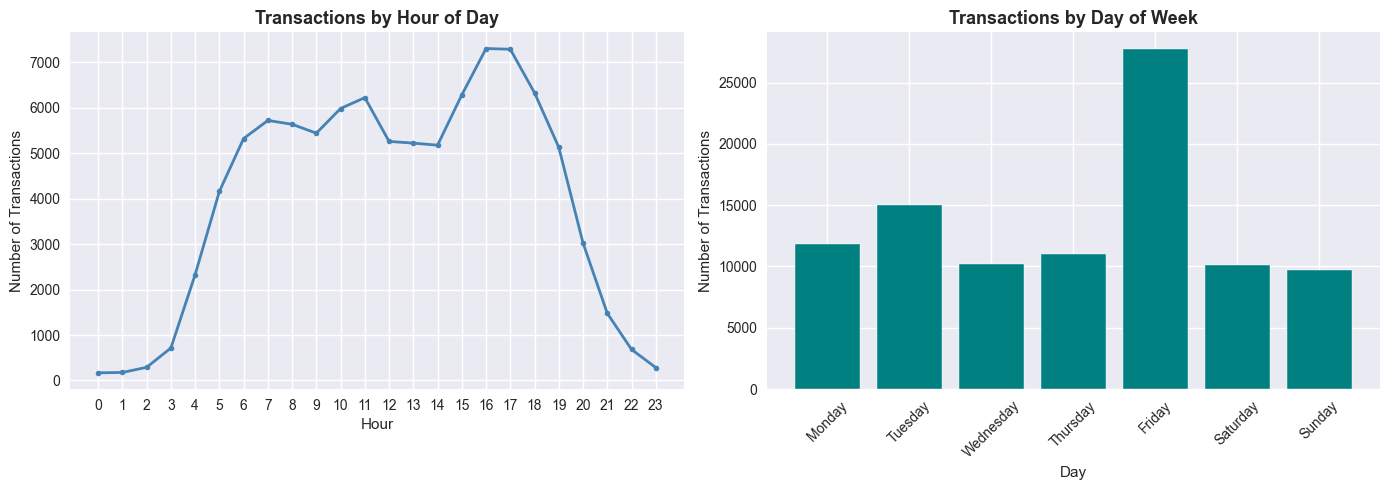

In [10]:
# Parse timestamp and analyze over time
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])
df['hour'] = df['TransactionStartTime'].dt.hour
df['day_of_week'] = df['TransactionStartTime'].dt.day_name()
df['month'] = df['TransactionStartTime'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transactions by hour
hour_counts = df['hour'].value_counts().sort_index()
axes[0].plot(hour_counts.index, hour_counts.values,
             color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Transactions by Hour of Day', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticks(range(0, 24))

# Transactions by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df['day_of_week'].value_counts().reindex(day_order)
axes[1].bar(day_order, day_counts.values, color='teal', edgecolor='white')
axes[1].set_title('Transactions by Day of Week', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Transactions')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

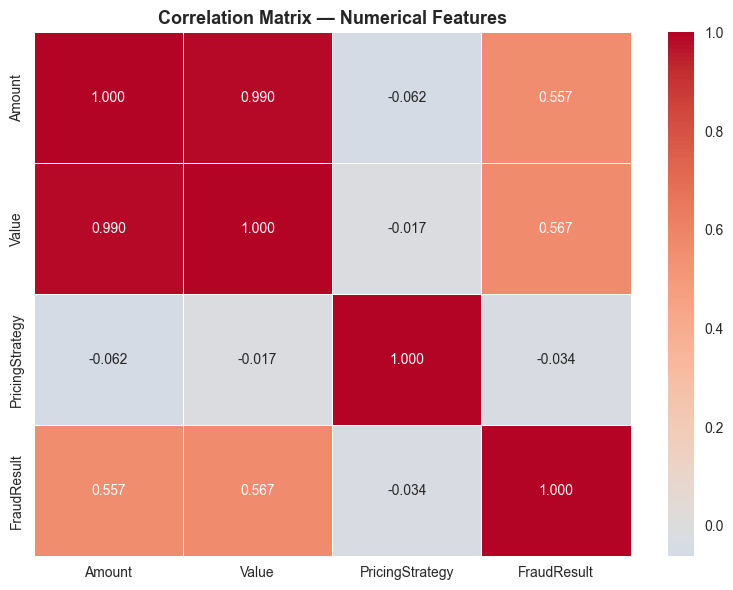

In [11]:
# Correlation between numerical features
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = df[['Amount', 'Value', 'PricingStrategy', 'FraudResult']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

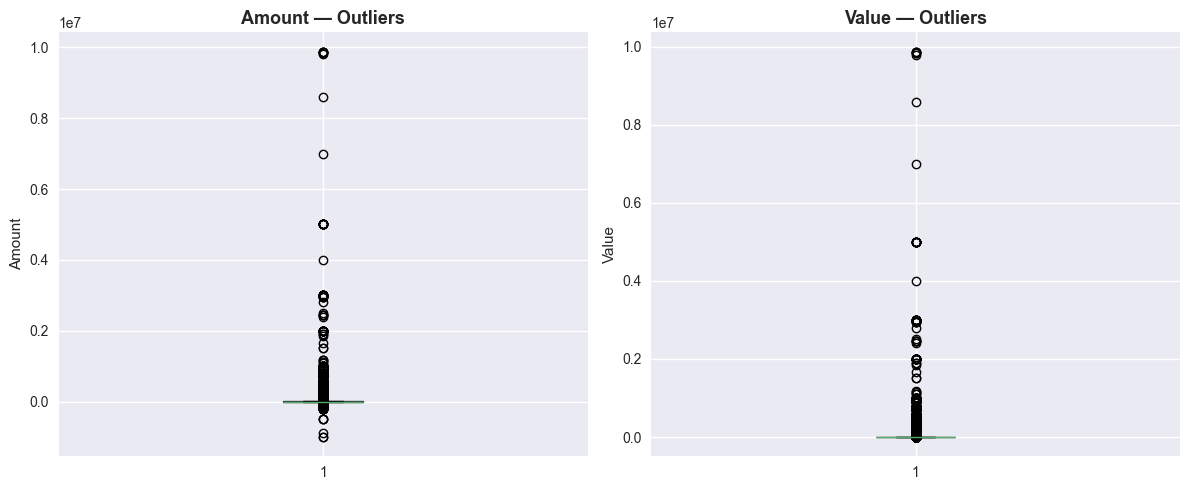

Amount: 24,441 outliers (25.5%)
Value: 9,021 outliers (9.4%)


In [12]:
# Outlier detection with boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df['Amount'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[0].set_title('Amount — Outliers', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Amount')

axes[1].boxplot(df['Value'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.7))
axes[1].set_title('Value — Outliers', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

# Quantify outliers using IQR
for col in ['Amount', 'Value']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers):,} outliers ({len(outliers)/len(df)*100:.1f}%)")

Total unique customers: 3,742
Average transactions per customer: 25.6
Max transactions by one customer: 4,091
Min transactions by one customer: 1


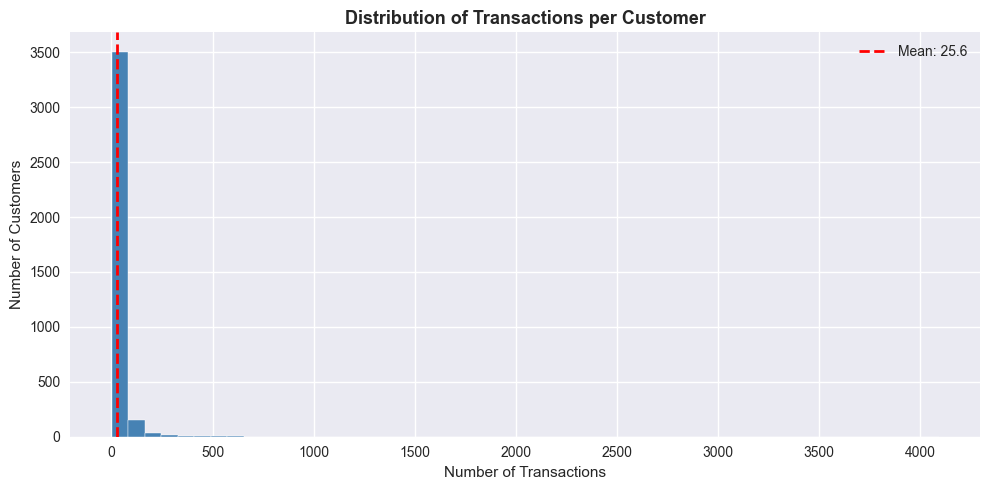

In [13]:
# How many transactions per customer?
customer_txn = df.groupby('CustomerId').size()

print(f"Total unique customers: {customer_txn.shape[0]:,}")
print(f"Average transactions per customer: {customer_txn.mean():.1f}")
print(f"Max transactions by one customer: {customer_txn.max():,}")
print(f"Min transactions by one customer: {customer_txn.min():,}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(customer_txn.values, bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Transactions per Customer', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Transactions')
ax.set_ylabel('Number of Customers')
ax.axvline(customer_txn.mean(), color='red', linestyle='--',
           linewidth=2, label=f'Mean: {customer_txn.mean():.1f}')
ax.legend()
plt.tight_layout()
plt.show()

## Top 5 EDA Insights

**Insight 1 — Severe class imbalance in fraud labels:**
Only 0.20% of transactions (193 out of 95,662) are flagged as fraudulent.
This confirms we cannot use FraudResult as a credit risk target — it is too rare
and represents fraud, not default risk. A proxy variable via RFM clustering is necessary.

**Insight 2 — Transaction amounts are heavily right-skewed with extreme outliers:**
The Amount ranges from -1,000,000 to 9,880,000 UGX. About 39.9% of transactions
have negative amounts (credits/reversals). Extreme outliers will require robust
scaling (e.g. StandardScaler or log transformation) before modeling.

**Insight 3 — Two product categories dominate completely:**
Financial services (45,405) and airtime (45,027) together account for over 94%
of all transactions. All other categories are negligible. This suggests the platform
is primarily a payments and airtime top-up service — important context for
interpreting RFM monetary value.

**Insight 4 — Strong temporal patterns exist in transaction behavior:**
Transaction volume peaks at 17:00 (evening) and drops sharply after 20:00.
Friday is the busiest day by far. These time-based patterns can be engineered
as features (hour, day_of_week) to capture behavioral signals.

**Insight 5 — Amount and Value are nearly perfectly correlated (0.99):**
Value is essentially the absolute value of Amount. Including both in a model
would cause multicollinearity. We will use Amount only and drop Value,
or engineer a single feature from both. FraudResult correlates moderately
with Amount (0.557) — larger transactions are more likely to be flagged.